Implementation of Linear Regression Algorithm

In [288]:
from dataclasses import dataclass
import numpy as np
import pandas as pd
import plotly.express as px

In [289]:
data=pd.read_csv("https://download.mlcc.google.com/mledu-datasets/chicago_taxi_train.csv")

In [290]:
training_df = data.loc[:, ('TRIP_MILES','TRIP_SECONDS','FARE','COMPANY','PAYMENT_TYPE','TIP_RATE')]

In [291]:
training_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31694 entries, 0 to 31693
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TRIP_MILES    31694 non-null  float64
 1   TRIP_SECONDS  31694 non-null  int64  
 2   FARE          31694 non-null  float64
 3   COMPANY       31694 non-null  object 
 4   PAYMENT_TYPE  31694 non-null  object 
 5   TIP_RATE      31694 non-null  float64
dtypes: float64(3), int64(1), object(2)
memory usage: 1.5+ MB


In [292]:
training_df.head()

,TRIP_MILES,TRIP_SECONDS,FARE,COMPANY,PAYMENT_TYPE,TIP_RATE
0,2.57,2341,31.99,Flash Cab,Mobile,6.3
1,1.18,1074,9.75,Flash Cab,Credit Card,27.9
2,1.29,1173,10.25,Sun Taxi,Cash,0.0
3,3.70,3360,23.75,Choice Taxi Association,Cash,0.0
4,1.15,1044,10.00,Flash Cab,Cash,0.0


what is the maximum fare.... what is the mean distance across all trips... what is the most frequent payment type..... how many cab companies are in the dataset.... are there any missing features in the data

In [293]:
training_df['FARE'].max()

np.float64(159.25)

In [294]:
training_df['TRIP_SECONDS'].mean()

np.float64(1319.796396794346)

In [295]:
training_df['PAYMENT_TYPE'].value_counts().idxmax()

'Credit Card'

In [296]:
training_df['COMPANY'].nunique()

31

In [297]:
training_df.isnull().any()

TRIP_MILES      False
TRIP_SECONDS    False
FARE            False
COMPANY         False
PAYMENT_TYPE    False
TIP_RATE        False
dtype: bool

In [298]:
# Finding the correlation matrix to know how the features are correlated with the target varible.

training_df.corr(numeric_only=True)

,TRIP_MILES,TRIP_SECONDS,FARE,TIP_RATE
TRIP_MILES,1.000000,0.800855,0.975344,-0.049594
TRIP_SECONDS,0.800855,1.000000,0.830292,-0.084294
FARE,0.975344,0.830292,1.000000,-0.070979
TIP_RATE,-0.049594,-0.084294,-0.070979,1.000000


In [299]:
px.scatter_matrix(training_df, dimensions = ["FARE","TRIP_MILES","TRIP_SECONDS","TIP_RATE"])

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'dimensions': [{'axis': {'matches': True},
                              'label': 'FARE',
                              'values': {'bdata': ('PQrXo3D9P0AAAAAAAIAjQAAAAAAAgC' ... 'AAwD5AAAAAAADgREAAAAAAAKBHQA=='),
                                         'dtype': 'f8'}},
                             {'axis': {'matches': True},
                              'label': 'TRIP_MILES',
                              'values': {'bdata': ('j8L1KFyPBEDhehSuR+HyP6RwPQrXo/' ... '6FayhAzczMzMxMQkCamZmZmVlCQA=='),
                                         'dtype': 'f8'}},
                             {'axis': {'matches': True},
                              'label': 'TRIP_SECONDS',
                              'values': {'bdata': ('JQkyBJUEIA0UBOMEFQdBBxMDdwVeDx' ... 'PcBUgD3QKHCxAB4wLMBq8C+Af4Bw=='),
                                         'dtype': 'i2'}},
                             {'axis': {'matches': True},
                              'label': 'TIP_RATE',
                              'values': {'bdata': ('MzMzMzMzGUBmZmZmZuY7QAAAAAAAAA' ... 'AAAAAAMzMzMzMzOUAzMzMzMzMjQA=='),
                                         'dtype': 'f8'}}],
              'hovertemplate': '%{xaxis.title.text}=%{x}<br>%{yaxis.title.text}=%{y}<extra></extra>',
              'legendgroup': '',
              'marker': {'color': '#636efa', 'symbol': 'circle'},
              'name': '',
              'showlegend': False,
              'type': 'splom'}],
    'layout': {'dragmode': 'select', 'legend': {'tracegroupgap': 0}, 'margin': {'t': 60}, 'template': '...'}
})

Implementing Linear Regression From Scratch

In [300]:
@dataclass
class ExperimentSettings:
    learning_rate: float
    number_epochs: int
    batch_size: int
    input_features: list
    optimizer: str = "batch"

1. BATCH GRADIENT DESCENT 
2. MINIBATCH GD
3. STOCHASTIC GD

^
y = W1X1 + W2X2 + ..... + b
^
y = XW + b

X = input features(nxm)
W = weights(shape?)
b = bias
^
y = prediction
n = number of data points
m = ?

-------------------------------------------------------------------------------------------------

Loss Function:
----------------
if the bias is -ve it means we have to increase the bias to reduce the loss and vice versa.

In [301]:
class LinearRegressionModel:
    def __init__(self,n_features,learning_rate,optimizer='batch',batch_size=32):
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.lr = learning_rate
        self.optimizer = optimizer
        self.batch_size = batch_size

    def predict(self,X):
        return X@self.weights + self.bias
    def compute_gradients(self,X,y):
        y_pred = self.predict(X)
        error = y_pred - y
        n = len(y)
        dw = (1/n) * (X.T@error)
        db = (1/n) * np.sum(error)
        return dw, db
    
    def update_parameters(self,dw,db):
        self.weights -= self.lr * dw
        self.bias -= self.lr * db
    
    def mse(self,y,y_pred):
        return np.mean((y-y_pred)**2)

In [302]:
def create_model(settings: ExperimentSettings):
    model = LinearRegressionModel(
        n_features = len(settings.input_features),
        learning_rate = settings.learning_rate,
        optimizer = settings.optimizer,
        batch_size = settings.batch_size

    )
    return model

In [303]:
def train_model(experiment_name: str,model: LinearRegressionModel,dataset: pd.DataFrame,label_name: str,
                settings: ExperimentSettings,verbose: bool = True):
    
    X = dataset[settings.input_features].values
    y = dataset[label_name].values

    history= {
        "mse" : []
    }
    n_samples = len(y)
    for epoch in range(settings.number_epochs):
        if model.optimizer == "batch":
            dw,db = model.compute_gradients(X,y)
            model.update_parameters(dw,db)

        y_pred = model.predict(X)
        mse = model.mse(y,y_pred)
        history["mse"].append(mse)
        if verbose:
            print(f"Epoch{epoch+1:03d}/{settings.number_epochs} |"
                  f"MSE: {mse:.4f} |"
                  f"Weights:{model.weights}| Bias: {model.bias:.4f}")
    return {
            "name":experiment_name,
            "settings": settings,
            "model" : model,
            "metrics_history": pd.DataFrame(history)
        }

Epoch001/40 |MSE: 667.9568 |Weights:[0.31841617]| Bias: 0.0239
Epoch002/40 |MSE: 520.3739 |Weights:[0.59794549]| Bias: 0.0451
Epoch003/40 |MSE: 406.6210 |Weights:[0.84333494]| Bias: 0.0641
Epoch004/40 |MSE: 318.9428 |Weights:[1.05875201]| Bias: 0.0809
Epoch005/40 |MSE: 251.3621 |Weights:[1.24785547]| Bias: 0.0959
Epoch006/40 |MSE: 199.2717 |Weights:[1.41385745]| Bias: 0.1094
Epoch007/40 |MSE: 159.1204 |Weights:[1.55957799]| Bias: 0.1215
Epoch008/40 |MSE: 128.1715 |Weights:[1.68749287]| Bias: 0.1323
Epoch009/40 |MSE: 104.3154 |Weights:[1.79977566]| Bias: 0.1421
Epoch010/40 |MSE: 85.9260 |Weights:[1.89833458]| Bias: 0.1510
Epoch011/40 |MSE: 71.7502 |Weights:[1.98484494]| Bias: 0.1590
Epoch012/40 |MSE: 60.8221 |Weights:[2.06077752]| Bias: 0.1663
Epoch013/40 |MSE: 52.3972 |Weights:[2.12742357]| Bias: 0.1729
Epoch014/40 |MSE: 45.9016 |Weights:[2.18591672]| Bias: 0.1790
Epoch015/40 |MSE: 40.8931 |Weights:[2.2372522]| Bias: 0.1846
Epoch016/40 |MSE: 37.0308 |Weights:[2.28230377]| Bias: 0.1898


<Axes: >

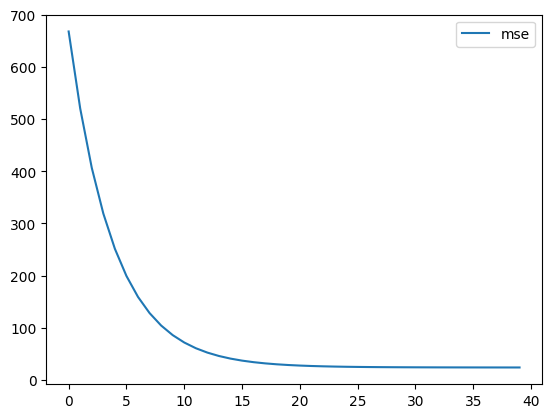

In [304]:
settings_1 = ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 40,
    batch_size = 50,
    input_features = ['TRIP_MILES'],
    optimizer = "batch"
)

model_1 = create_model(settings_1)
experiment_1 = train_model(
    experiment_name = "one_feature",
    model = model_1,
    dataset = training_df,
    label_name = "FARE",
    settings = settings_1
)
experiment_1["metrics_history"][["mse"]].plot()

Epoch001/40 |MSE: 64.8122 |Weights:[3.1841617]| Bias: 0.2391
Epoch002/40 |MSE: 26.0209 |Weights:[2.47963892]| Bias: 0.2118
Epoch003/40 |MSE: 24.0490 |Weights:[2.63339813]| Bias: 0.2431
Epoch004/40 |MSE: 23.8715 |Weights:[2.59773279]| Bias: 0.2615
Epoch005/40 |MSE: 23.7821 |Weights:[2.60388296]| Bias: 0.2826
Epoch006/40 |MSE: 23.6977 |Weights:[2.60081144]| Bias: 0.3030
Epoch007/40 |MSE: 23.6142 |Weights:[2.59978266]| Bias: 0.3234
Epoch008/40 |MSE: 23.5314 |Weights:[2.59831041]| Bias: 0.3437
Epoch009/40 |MSE: 23.4494 |Weights:[2.59694338]| Bias: 0.3639
Epoch010/40 |MSE: 23.3681 |Weights:[2.59556045]| Bias: 0.3841
Epoch011/40 |MSE: 23.2874 |Weights:[2.59418831]| Bias: 0.4041
Epoch012/40 |MSE: 23.2075 |Weights:[2.59282105]| Bias: 0.4241
Epoch013/40 |MSE: 23.1283 |Weights:[2.59145993]| Bias: 0.4440
Epoch014/40 |MSE: 23.0497 |Weights:[2.59010464]| Bias: 0.4638
Epoch015/40 |MSE: 22.9718 |Weights:[2.58875523]| Bias: 0.4835
Epoch016/40 |MSE: 22.8946 |Weights:[2.58741165]| Bias: 0.5031
Epoch017/

<Axes: >

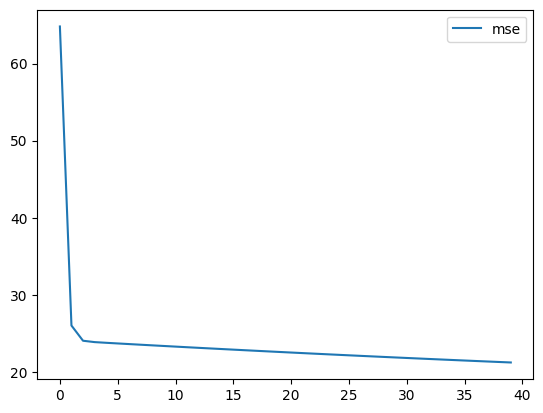

In [305]:
settings_2 = ExperimentSettings(
    learning_rate = 0.01,
    number_epochs = 40,
    batch_size = 50,
    input_features = ['TRIP_MILES'],
    optimizer = "batch"
)

model_2 = create_model(settings_2)
experiment_2 = train_model(
    experiment_name = "one_feature",
    model = model_2,
    dataset = training_df,
    label_name = "FARE",
    settings = settings_2
)
experiment_2["metrics_history"][["mse"]].plot()

Epoch001/80 |MSE: 667.9568 |Weights:[0.31841617]| Bias: 0.0239
Epoch002/80 |MSE: 520.3739 |Weights:[0.59794549]| Bias: 0.0451
Epoch003/80 |MSE: 406.6210 |Weights:[0.84333494]| Bias: 0.0641
Epoch004/80 |MSE: 318.9428 |Weights:[1.05875201]| Bias: 0.0809
Epoch005/80 |MSE: 251.3621 |Weights:[1.24785547]| Bias: 0.0959
Epoch006/80 |MSE: 199.2717 |Weights:[1.41385745]| Bias: 0.1094
Epoch007/80 |MSE: 159.1204 |Weights:[1.55957799]| Bias: 0.1215
Epoch008/80 |MSE: 128.1715 |Weights:[1.68749287]| Bias: 0.1323
Epoch009/80 |MSE: 104.3154 |Weights:[1.79977566]| Bias: 0.1421
Epoch010/80 |MSE: 85.9260 |Weights:[1.89833458]| Bias: 0.1510
Epoch011/80 |MSE: 71.7502 |Weights:[1.98484494]| Bias: 0.1590
Epoch012/80 |MSE: 60.8221 |Weights:[2.06077752]| Bias: 0.1663
Epoch013/80 |MSE: 52.3972 |Weights:[2.12742357]| Bias: 0.1729
Epoch014/80 |MSE: 45.9016 |Weights:[2.18591672]| Bias: 0.1790
Epoch015/80 |MSE: 40.8931 |Weights:[2.2372522]| Bias: 0.1846
Epoch016/80 |MSE: 37.0308 |Weights:[2.28230377]| Bias: 0.1898


<Axes: >

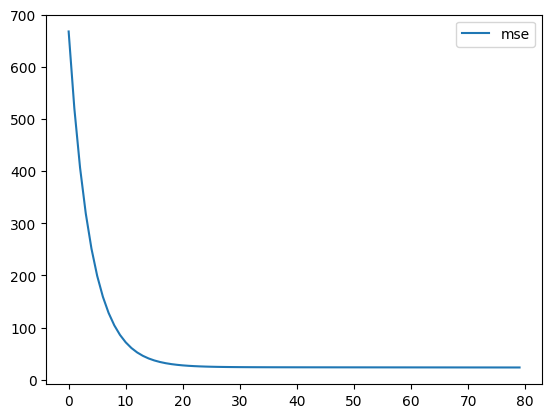

In [306]:
settings_3 = ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 80,
    batch_size = 50,
    input_features = ['TRIP_MILES'],
    optimizer = "batch"
)

model_3 = create_model(settings_3)
experiment_3 = train_model(
    experiment_name = "one_feature",
    model = model_3,
    dataset = training_df,
    label_name = "FARE",
    settings = settings_3
)
experiment_3["metrics_history"][["mse"]].plot()

Epoch001/80 |MSE: 64.8122 |Weights:[3.1841617]| Bias: 0.2391
Epoch002/80 |MSE: 26.0209 |Weights:[2.47963892]| Bias: 0.2118
Epoch003/80 |MSE: 24.0490 |Weights:[2.63339813]| Bias: 0.2431
Epoch004/80 |MSE: 23.8715 |Weights:[2.59773279]| Bias: 0.2615
Epoch005/80 |MSE: 23.7821 |Weights:[2.60388296]| Bias: 0.2826
Epoch006/80 |MSE: 23.6977 |Weights:[2.60081144]| Bias: 0.3030
Epoch007/80 |MSE: 23.6142 |Weights:[2.59978266]| Bias: 0.3234
Epoch008/80 |MSE: 23.5314 |Weights:[2.59831041]| Bias: 0.3437
Epoch009/80 |MSE: 23.4494 |Weights:[2.59694338]| Bias: 0.3639
Epoch010/80 |MSE: 23.3681 |Weights:[2.59556045]| Bias: 0.3841
Epoch011/80 |MSE: 23.2874 |Weights:[2.59418831]| Bias: 0.4041
Epoch012/80 |MSE: 23.2075 |Weights:[2.59282105]| Bias: 0.4241
Epoch013/80 |MSE: 23.1283 |Weights:[2.59145993]| Bias: 0.4440
Epoch014/80 |MSE: 23.0497 |Weights:[2.59010464]| Bias: 0.4638
Epoch015/80 |MSE: 22.9718 |Weights:[2.58875523]| Bias: 0.4835
Epoch016/80 |MSE: 22.8946 |Weights:[2.58741165]| Bias: 0.5031
Epoch017/

<Axes: >

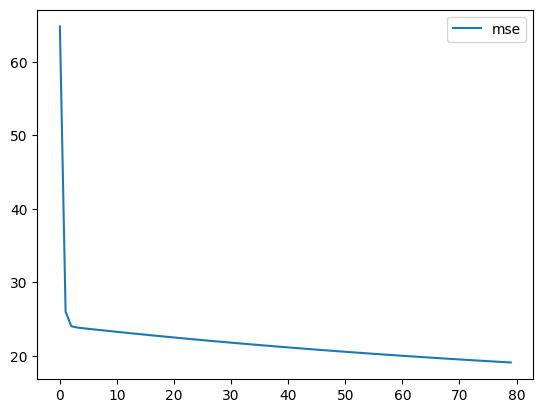

In [307]:
settings_4 = ExperimentSettings(
    learning_rate = 0.01,
    number_epochs = 80,
    batch_size = 50,
    input_features = ['TRIP_MILES'],
    optimizer = "batch"
)

model_4 = create_model(settings_4)
experiment_4 = train_model(
    experiment_name = "one_feature",
    model = model_4,
    dataset = training_df,
    label_name = "FARE",
    settings = settings_4
)
experiment_4["metrics_history"][["mse"]].plot()

Epoch001/400 |MSE: 839.1640 |Weights:[0.03184162]| Bias: 0.0024
Epoch002/400 |MSE: 819.3882 |Weights:[0.06329437]| Bias: 0.0048
Epoch003/400 |MSE: 800.0922 |Weights:[0.09436299]| Bias: 0.0071
Epoch004/400 |MSE: 781.2644 |Weights:[0.12505219]| Bias: 0.0094
Epoch005/400 |MSE: 762.8935 |Weights:[0.15536658]| Bias: 0.0117
Epoch006/400 |MSE: 744.9683 |Weights:[0.18531075]| Bias: 0.0140
Epoch007/400 |MSE: 727.4780 |Weights:[0.21488921]| Bias: 0.0162
Epoch008/400 |MSE: 710.4121 |Weights:[0.24410643]| Bias: 0.0184
Epoch009/400 |MSE: 693.7603 |Weights:[0.27296682]| Bias: 0.0206
Epoch010/400 |MSE: 677.5126 |Weights:[0.30147473]| Bias: 0.0227
Epoch011/400 |MSE: 661.6591 |Weights:[0.32963447]| Bias: 0.0249
Epoch012/400 |MSE: 646.1902 |Weights:[0.35745029]| Bias: 0.0270
Epoch013/400 |MSE: 631.0967 |Weights:[0.38492638]| Bias: 0.0291
Epoch014/400 |MSE: 616.3694 |Weights:[0.41206689]| Bias: 0.0312
Epoch015/400 |MSE: 601.9995 |Weights:[0.43887592]| Bias: 0.0332
Epoch016/400 |MSE: 587.9782 |Weights:[0.

<Axes: >

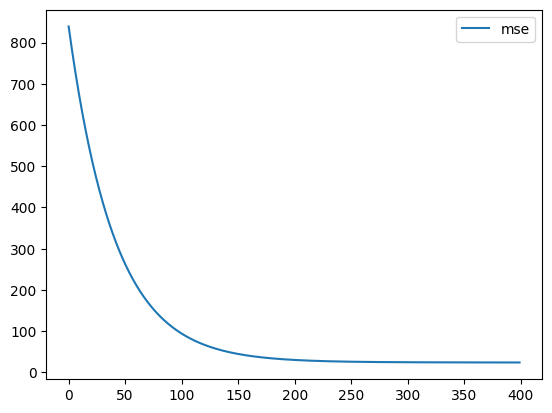

In [308]:
settings_5 = ExperimentSettings(
    learning_rate = 0.0001,
    number_epochs = 400,
    batch_size = 50,
    input_features = ['TRIP_MILES'],
    optimizer = "batch"
)

model_5 = create_model(settings_5)
experiment_5 = train_model(
    experiment_name = "one_feature",
    model = model_5,
    dataset = training_df,
    label_name = "FARE",
    settings = settings_5
)
experiment_5["metrics_history"][["mse"]].plot()

Epoch001/40 |MSE: 839.1640 |Weights:[0.03184162]| Bias: 0.0024
Epoch002/40 |MSE: 819.3882 |Weights:[0.06329437]| Bias: 0.0048
Epoch003/40 |MSE: 800.0922 |Weights:[0.09436299]| Bias: 0.0071
Epoch004/40 |MSE: 781.2644 |Weights:[0.12505219]| Bias: 0.0094
Epoch005/40 |MSE: 762.8935 |Weights:[0.15536658]| Bias: 0.0117
Epoch006/40 |MSE: 744.9683 |Weights:[0.18531075]| Bias: 0.0140
Epoch007/40 |MSE: 727.4780 |Weights:[0.21488921]| Bias: 0.0162
Epoch008/40 |MSE: 710.4121 |Weights:[0.24410643]| Bias: 0.0184
Epoch009/40 |MSE: 693.7603 |Weights:[0.27296682]| Bias: 0.0206
Epoch010/40 |MSE: 677.5126 |Weights:[0.30147473]| Bias: 0.0227
Epoch011/40 |MSE: 661.6591 |Weights:[0.32963447]| Bias: 0.0249
Epoch012/40 |MSE: 646.1902 |Weights:[0.35745029]| Bias: 0.0270
Epoch013/40 |MSE: 631.0967 |Weights:[0.38492638]| Bias: 0.0291
Epoch014/40 |MSE: 616.3694 |Weights:[0.41206689]| Bias: 0.0312
Epoch015/40 |MSE: 601.9995 |Weights:[0.43887592]| Bias: 0.0332
Epoch016/40 |MSE: 587.9782 |Weights:[0.46535752]| Bias:

<Axes: >

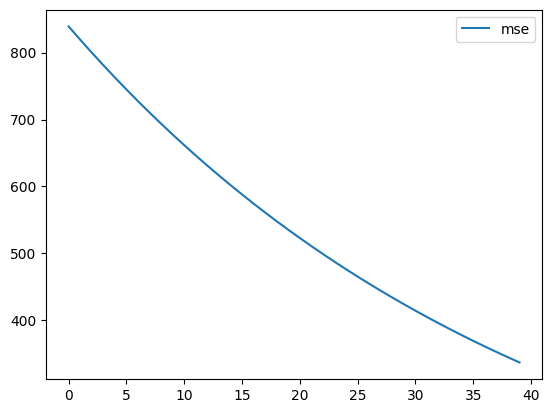

In [309]:
settings_6 = ExperimentSettings(
    learning_rate = 0.0001,
    number_epochs = 40,
    batch_size = 50,
    input_features = ['TRIP_MILES'],
    optimizer = "batch"
)

model_6 = create_model(settings_6)
experiment_5 = train_model(
    experiment_name = "one_feature",
    model = model_6,
    dataset = training_df,
    label_name = "FARE",
    settings = settings_6
)
experiment_5["metrics_history"][["mse"]].plot()

Epoch001/40 |MSE: 104926.0621 |Weights:[31.84161696]| Bias: 2.3905
Epoch002/40 |MSE: 13175724.9940 |Weights:[-325.18521294]| Bias: -21.8530
Epoch003/40 |MSE: 1654858453.9125 |Weights:[3675.88595534]| Bias: 252.2839
Epoch004/40 |MSE: 207848989057.3266 |Weights:[-41164.70807119]| Bias: -2817.6659
Epoch005/40 |MSE: 26105678531839.1367 |Weights:[461368.49319675]| Bias: 31589.8223
Epoch006/40 |MSE: 3278853819626393.0000 |Weights:[-5170575.22147235]| Bias: -354016.4598
Epoch007/40 |MSE: 411821602620858176.0000 |Weights:[57947222.83017772]| Bias: 3967516.6071
Epoch008/40 |MSE: 51724487188189954048.0000 |Weights:[-6.4942072e+08]| Bias: -44464366.7363
Epoch009/40 |MSE: 6496557144779853398016.0000 |Weights:[7.2781278e+09]| Bias: 498316954.2956
Epoch010/40 |MSE: 815962748588191591170048.0000 |Weights:[-8.15667601e+10]| Bias: -5584691614.0757
Epoch011/40 |MSE: 102484314729468556933595136.0000 |Weights:[9.14127442e+11]| Bias: 62588238847.7556
Epoch012/40 |MSE: 12871953754925082807801741312.0000 |We

<Axes: >

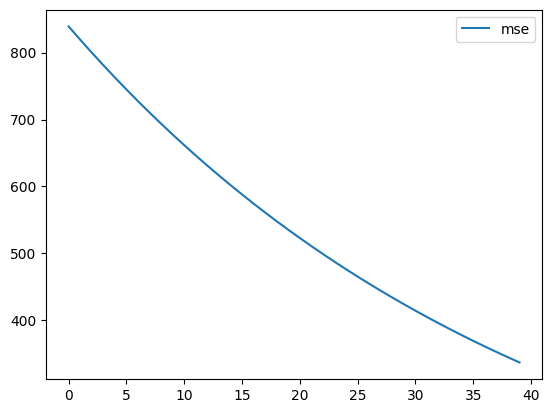

In [310]:
settings_7 = ExperimentSettings(
    learning_rate = 0.1,
    number_epochs = 40,
    batch_size = 50,
    input_features = ['TRIP_MILES'],
    optimizer = "batch"
)

model_7 = create_model(settings_7)
experiment_7 = train_model(
    experiment_name = "one_feature",
    model = model_7,
    dataset = training_df,
    label_name = "FARE",
    settings = settings_7
)
experiment_5["metrics_history"][["mse"]].plot()

applying mini-batch gradient descent

In [311]:
class LinearRegressionModel:
    def __init__(self,n_features,learning_rate,optimizer='mini_batch',batch_size=32):
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.lr = learning_rate
        self.optimizer = optimizer
        self.batch_size = batch_size

    def predict(self,X):
        return X@self.weights + self.bias
    def compute_gradients(self,X,y):
        y_pred = self.predict(X)
        error = y_pred - y
        n = len(y)
        dw = (1/n) * (X.T@error)
        db = (1/n) * np.sum(error)
        return dw, db
    
    def update_parameters(self,dw,db):
        self.weights -= self.lr * dw
        self.bias -= self.lr * db
    
    def mse(self,y,y_pred):
        return np.mean((y-y_pred)**2)

In [312]:
def create_model(settings: ExperimentSettings):
    model = LinearRegressionModel(
        n_features = len(settings.input_features),
        learning_rate = settings.learning_rate,
        optimizer = settings.optimizer,
        batch_size = settings.batch_size

    )
    return model

In [313]:
def train_model(experiment_name: str,model: LinearRegressionModel,dataset: pd.DataFrame,label_name: str,
                settings: ExperimentSettings,verbose: bool = True):
    
    X = dataset[settings.input_features].values
    y = dataset[label_name].values

    history= {
        "mse" : []
    }
    n_samples = len(y)
    for epoch in range(settings.number_epochs):
        if model.optimizer == "mini_batch":
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

    for i in range(0, n_samples, model.batch_size):
        X_batch = X_shuffled[i:i+model.batch_size]
        y_batch = y_shuffled[i:i+model.batch_size]

        dw, db = model.compute_gradients(X_batch, y_batch)
        model.update_parameters(dw, db)


        y_pred = model.predict(X)
        mse = model.mse(y,y_pred)
        history["mse"].append(mse)
        if verbose:
            print(f"Epoch{epoch+1:03d}/{settings.number_epochs} |"
                  f"MSE: {mse:.4f} |"
                  f"Weights:{model.weights}| Bias: {model.bias:.4f}")
    return {
            "name":experiment_name,
            "settings": settings,
            "model" : model,
            "metrics_history": pd.DataFrame(history)
        }

Epoch040/40 |MSE: 656.4389 |Weights:[0.33910512]| Bias: 0.0240
Epoch040/40 |MSE: 477.9831 |Weights:[0.68607278]| Bias: 0.0474
Epoch040/40 |MSE: 387.1504 |Weights:[0.88913245]| Bias: 0.0639
Epoch040/40 |MSE: 331.0853 |Weights:[1.02725303]| Bias: 0.0773
Epoch040/40 |MSE: 278.8627 |Weights:[1.16782705]| Bias: 0.0905
Epoch040/40 |MSE: 216.4581 |Weights:[1.35662281]| Bias: 0.1051
Epoch040/40 |MSE: 167.7648 |Weights:[1.52656456]| Bias: 0.1185
Epoch040/40 |MSE: 140.6496 |Weights:[1.63384984]| Bias: 0.1283
Epoch040/40 |MSE: 120.0497 |Weights:[1.72395645]| Bias: 0.1374
Epoch040/40 |MSE: 100.2711 |Weights:[1.82016715]| Bias: 0.1465
Epoch040/40 |MSE: 82.3844 |Weights:[1.9187329]| Bias: 0.1550
Epoch040/40 |MSE: 69.9186 |Weights:[1.99667643]| Bias: 0.1626
Epoch040/40 |MSE: 58.0360 |Weights:[2.08166977]| Bias: 0.1705
Epoch040/40 |MSE: 48.9363 |Weights:[2.15753829]| Bias: 0.1771
Epoch040/40 |MSE: 46.3492 |Weights:[2.18127444]| Bias: 0.1818
Epoch040/40 |MSE: 41.2924 |Weights:[2.23252213]| Bias: 0.1875

<Axes: >

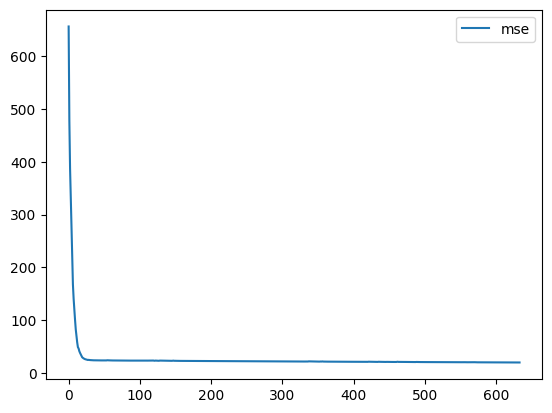

In [314]:
settings_1 = ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 40,
    batch_size = 50,
    input_features = ['TRIP_MILES'],
    optimizer = "mini_batch"
)

model_1 = create_model(settings_1)
experiment_1 = train_model(
    experiment_name = "one_feature",
    model = model_1,
    dataset = training_df,
    label_name = "FARE",
    settings = settings_1
)
experiment_1["metrics_history"][["mse"]].plot()

applying stochastic gradient descent

In [315]:
class LinearRegressionModel:
    def __init__(self,n_features,learning_rate,optimizer='batch',batch_size=32):
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.lr = learning_rate
        self.optimizer = optimizer
        self.batch_size = batch_size

    def predict(self,X):
        return X@self.weights + self.bias
    def compute_gradients(self,X,y):
        y_pred = self.predict(X)
        error = y_pred - y
        n = len(y)
        dw = (1/n) * (X.T@error)
        db = (1/n) * np.sum(error)
        return dw, db
    
    def update_parameters(self,dw,db):
        self.weights -= self.lr * dw
        self.bias -= self.lr * db
    
    def mse(self,y,y_pred):
        return np.mean((y-y_pred)**2)

In [316]:
def train_model(
    experiment_name: str,
    model: LinearRegressionModel,
    dataset: pd.DataFrame,
    label_name: str,
    settings: ExperimentSettings,
    verbose: bool = True
):

    X = dataset[settings.input_features].values
    y = dataset[label_name].values

    history = {"mse": []}
    n_samples = len(y)

    for epoch in range(settings.number_epochs):

        # ---- SGD: shuffle every epoch ----
        indices = np.random.permutation(n_samples)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        # ---- one update per sample ----
        for i in range(n_samples):
            X_i = X_shuffled[i:i+1]   # shape (1, n_features)
            y_i = y_shuffled[i:i+1]   # shape (1,)

            dw, db = model.compute_gradients(X_i, y_i)
            model.update_parameters(dw, db)

        # ---- evaluate once per epoch ----
        y_pred = model.predict(X)
        mse = model.mse(y, y_pred)
        history["mse"].append(mse)

        if verbose:
            print(
                f"Epoch {epoch+1:03d}/{settings.number_epochs} | "
                f"MSE: {mse:.4f} | "
                f"Weights: {model.weights} | Bias: {model.bias:.4f}"
            )

    return {
        "name": experiment_name,
        "settings": settings,
        "model": model,
        "metrics_history": pd.DataFrame(history)
    }


Epoch 001/40 | MSE: 14.0931 | Weights: [2.3028267] | Bias: 5.0046
Epoch 002/40 | MSE: 14.0257 | Weights: [2.27539174] | Bias: 5.0567
Epoch 003/40 | MSE: 14.0285 | Weights: [2.27200404] | Bias: 5.0335
Epoch 004/40 | MSE: 14.0267 | Weights: [2.2769464] | Bias: 5.0686
Epoch 005/40 | MSE: 14.0326 | Weights: [2.28864646] | Bias: 4.9728
Epoch 006/40 | MSE: 14.1027 | Weights: [2.25137428] | Bias: 5.0427
Epoch 007/40 | MSE: 14.0902 | Weights: [2.24533927] | Bias: 5.2004
Epoch 008/40 | MSE: 14.0844 | Weights: [2.24838213] | Bias: 5.1545
Epoch 009/40 | MSE: 14.0567 | Weights: [2.29604609] | Bias: 4.9923
Epoch 010/40 | MSE: 14.4809 | Weights: [2.21901688] | Bias: 4.9895
Epoch 011/40 | MSE: 14.4864 | Weights: [2.21683355] | Bias: 5.0156
Epoch 012/40 | MSE: 14.2317 | Weights: [2.31666673] | Bias: 5.0588
Epoch 013/40 | MSE: 19.4502 | Weights: [2.48329127] | Bias: 5.1094
Epoch 014/40 | MSE: 14.0653 | Weights: [2.25062881] | Bias: 5.2269
Epoch 015/40 | MSE: 15.0511 | Weights: [2.37006366] | Bias: 5.01

<Axes: >

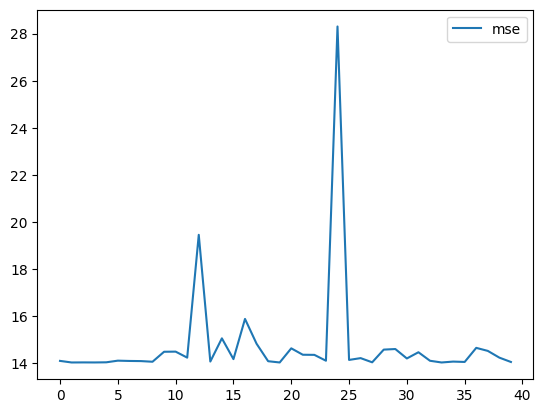

In [317]:
settings_1 = ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 40,
    batch_size = 50,
    input_features = ['TRIP_MILES'],
    optimizer = "stochastic_gradient_descent"
)

model_1 = create_model(settings_1)
experiment_1 = train_model(
    experiment_name = "one_feature",
    model = model_1,
    dataset = training_df,
    label_name = "FARE",
    settings = settings_1
)
experiment_1["metrics_history"][["mse"]].plot()

**LAB 4**

*Logistic Regression*

In [2]:
from dataclasses import dataclass
import numpy as np
import pandas as pd
import plotly.express as px

In [3]:
import pandas as pd
irisdata = pd.read_csv('irisdata.csv')

In [4]:
irisdata["Type_binary"] = (irisdata["Type"] == 0).astype(int)

np.clip(ypred, e^-15 (min), 1-e^15(max)) --> do this before computing logloss

change from mse to logloss

function named predict probablities, threshold = 0.5

update parameters and compute gradient will remain the same.

In [5]:
@dataclass
class ExperimentSettings:
    learning_rate: float
    number_epochs: int
    batch_size: int
    input_features: list
    optimizer: str = "batch"
    model_name: str = "logistic_regression"

In [6]:
class LogisticRegressionModel:
    def __init__(self,n_features,learning_rate,optimizer='batch',batch_size=32):
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.lr = learning_rate
        self.optimizer = optimizer
        self.batch_size = batch_size


    def sigmoid(self, X):
        z = np.dot(X, self.weights) + self.bias
        return 1 / (1 + np.exp(-z))


    def predict_probability(self,X):
        y_pred = self.sigmoid(X)
        return y_pred   
    
    def predict(self,X):
        y_pred = self.predict_probability(X)
        return np.where(y_pred>0.5, 1, 0)
        

    def compute_gradients(self,X,y):
        y_pred = self.predict_probability(X)
        error = y_pred - y
        n = len(y)
        dw = (1/n) * (X.T@error)
        db = (1/n) * np.sum(error)
        return dw, db
    
    def update_parameters(self,dw,db):
        self.weights -= self.lr * dw
        self.bias -= self.lr * db
    
    def logloss(self,y,y_pred):
        y_pred_clip = np.clip(y_pred,1e-15,1-1e-15)
        loss =  -np.mean(y*np.log(y_pred_clip)+(1-y)*np.log(1-y_pred_clip))
        return loss

In [7]:
def create_model(settings: ExperimentSettings):
    model = LogisticRegressionModel(
        n_features = len(settings.input_features),
        learning_rate = settings.learning_rate,
        optimizer = settings.optimizer,
        batch_size = settings.batch_size,


    )
    return model

In [8]:
def train_model(experiment_name: str, model: LogisticRegressionModel, dataset: pd.DataFrame, 
                label_name: str, settings: ExperimentSettings, verbose: bool = True):
    
    X = dataset[settings.input_features].values
    y = dataset[label_name].values

    history = {"logloss": []}

    for epoch in range(settings.number_epochs):
        if model.optimizer == "batch":
            dw, db = model.compute_gradients(X, y)
            model.update_parameters(dw, db)

        # Compute probabilities and logloss inside the loop
        y_pred_prob = model.predict_probability(X)
        logloss = model.logloss(y, y_pred_prob)
        history["logloss"].append(logloss)

        if verbose:
            print(f"Epoch {epoch+1:03d}/{settings.number_epochs} | "
                  f"LogLoss: {logloss:.4f} | "
                  f"Weights: {model.weights} | Bias: {model.bias:.4f}")

    return {
        "name": experiment_name,
        "settings": settings,
        "model": model,
        "metrics_history": pd.DataFrame(history)
    }


Epoch 001/40 | LogLoss: 0.6931 | Weights: [-0.0002325] | Bias: 0.0000
Epoch 002/40 | LogLoss: 0.6930 | Weights: [-0.00046324] | Bias: 0.0000
Epoch 003/40 | LogLoss: 0.6930 | Weights: [-0.00069222] | Bias: 0.0000
Epoch 004/40 | LogLoss: 0.6929 | Weights: [-0.00091947] | Bias: 0.0000
Epoch 005/40 | LogLoss: 0.6929 | Weights: [-0.001145] | Bias: 0.0000
Epoch 006/40 | LogLoss: 0.6928 | Weights: [-0.00136882] | Bias: 0.0000
Epoch 007/40 | LogLoss: 0.6928 | Weights: [-0.00159095] | Bias: 0.0000
Epoch 008/40 | LogLoss: 0.6927 | Weights: [-0.00181139] | Bias: 0.0000
Epoch 009/40 | LogLoss: 0.6927 | Weights: [-0.00203016] | Bias: 0.0000
Epoch 010/40 | LogLoss: 0.6926 | Weights: [-0.00224728] | Bias: 0.0000
Epoch 011/40 | LogLoss: 0.6926 | Weights: [-0.00246275] | Bias: 0.0000
Epoch 012/40 | LogLoss: 0.6926 | Weights: [-0.0026766] | Bias: 0.0000
Epoch 013/40 | LogLoss: 0.6925 | Weights: [-0.00288882] | Bias: 0.0000
Epoch 014/40 | LogLoss: 0.6925 | Weights: [-0.00309945] | Bias: 0.0000
Epoch 015/

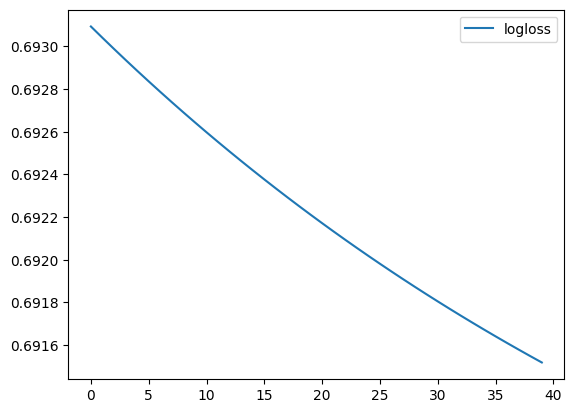

In [9]:
import matplotlib.pyplot as plt
settings_1 = ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 40,
    batch_size = 50,
    input_features = ['length'],
    optimizer = "batch",
    model_name = "logistic_regression"
)

model_1 = create_model(settings_1)
experiment_1 = train_model(
    experiment_name = "one_feature",
    model = model_1,
    dataset = irisdata,
    label_name = "Type_binary",
    settings = settings_1
    
)
experiment_1["metrics_history"][["logloss"]].plot()
plt.show()

changing the hyperparameters


Epoch 001/60 | LogLoss: 0.6926 | Weights: [0.002325] | Bias: 0.0000
Epoch 002/60 | LogLoss: 0.6922 | Weights: [0.00447365] | Bias: -0.0000
Epoch 003/60 | LogLoss: 0.6918 | Weights: [0.00645979] | Bias: -0.0001
Epoch 004/60 | LogLoss: 0.6915 | Weights: [0.00829614] | Bias: -0.0002
Epoch 005/60 | LogLoss: 0.6912 | Weights: [0.00999448] | Bias: -0.0003
Epoch 006/60 | LogLoss: 0.6910 | Weights: [0.01156563] | Bias: -0.0004
Epoch 007/60 | LogLoss: 0.6908 | Weights: [0.01301958] | Bias: -0.0006
Epoch 008/60 | LogLoss: 0.6906 | Weights: [0.01436553] | Bias: -0.0008
Epoch 009/60 | LogLoss: 0.6904 | Weights: [0.01561195] | Bias: -0.0010
Epoch 010/60 | LogLoss: 0.6903 | Weights: [0.01676665] | Bias: -0.0012
Epoch 011/60 | LogLoss: 0.6902 | Weights: [0.01783683] | Bias: -0.0014
Epoch 012/60 | LogLoss: 0.6901 | Weights: [0.01882911] | Bias: -0.0016
Epoch 013/60 | LogLoss: 0.6900 | Weights: [0.01974961] | Bias: -0.0019
Epoch 014/60 | LogLoss: 0.6899 | Weights: [0.02060394] | Bias: -0.0022
Epoch 015

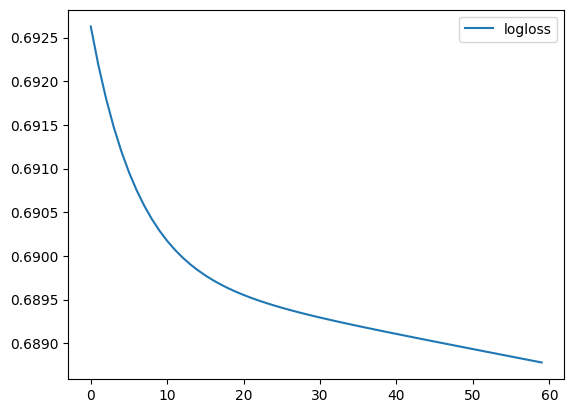

In [10]:
import matplotlib.pyplot as plt
settings_2 = ExperimentSettings(
    learning_rate = 0.01,
    number_epochs = 60,
    batch_size = 70,
    input_features = ['length'],
    optimizer = "batch",
    model_name = "logistic_regression"
)

model_2 = create_model(settings_2)
experiment_2 = train_model(
    experiment_name = "one_feature",
    model = model_2,
    dataset = irisdata,
    label_name = "Type",
    settings = settings_2
    
)
experiment_2["metrics_history"][["logloss"]].plot()
plt.show()

Epoch 001/40 | LogLoss: 0.6898 | Weights: [0.02325] | Bias: 0.0000
Epoch 002/40 | LogLoss: 0.6895 | Weights: [0.02889057] | Bias: -0.0032
Epoch 003/40 | LogLoss: 0.6893 | Weights: [0.0307077] | Bias: -0.0070
Epoch 004/40 | LogLoss: 0.6891 | Weights: [0.03168082] | Bias: -0.0111
Epoch 005/40 | LogLoss: 0.6890 | Weights: [0.03246642] | Bias: -0.0151
Epoch 006/40 | LogLoss: 0.6888 | Weights: [0.03321016] | Bias: -0.0192
Epoch 007/40 | LogLoss: 0.6886 | Weights: [0.03394441] | Bias: -0.0232
Epoch 008/40 | LogLoss: 0.6884 | Weights: [0.03467637] | Bias: -0.0273
Epoch 009/40 | LogLoss: 0.6883 | Weights: [0.03540763] | Bias: -0.0313
Epoch 010/40 | LogLoss: 0.6881 | Weights: [0.03613856] | Bias: -0.0354
Epoch 011/40 | LogLoss: 0.6879 | Weights: [0.03686924] | Bias: -0.0394
Epoch 012/40 | LogLoss: 0.6878 | Weights: [0.03759968] | Bias: -0.0435
Epoch 013/40 | LogLoss: 0.6876 | Weights: [0.03832988] | Bias: -0.0475
Epoch 014/40 | LogLoss: 0.6874 | Weights: [0.03905986] | Bias: -0.0516
Epoch 015/4

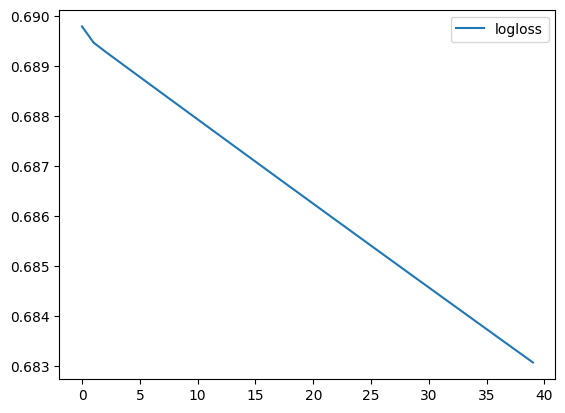

In [11]:
import matplotlib.pyplot as plt
settings_3 = ExperimentSettings(
    learning_rate = 0.1,
    number_epochs = 40,
    batch_size = 50,
    input_features = ['length'],
    optimizer = "batch",
    model_name = "logistic_regression"
)

model_3 = create_model(settings_3)
experiment_3 = train_model(
    experiment_name = "one_feature",
    model = model_3,
    dataset = irisdata,
    label_name = "Type",
    settings = settings_3
    
)
experiment_3["metrics_history"][["logloss"]].plot()
plt.show()

Epoch 001/70 | LogLoss: 0.6926 | Weights: [-0.002325] | Bias: 0.0000
Epoch 002/70 | LogLoss: 0.6922 | Weights: [-0.00447365] | Bias: 0.0000
Epoch 003/70 | LogLoss: 0.6918 | Weights: [-0.00645979] | Bias: 0.0001
Epoch 004/70 | LogLoss: 0.6915 | Weights: [-0.00829614] | Bias: 0.0002
Epoch 005/70 | LogLoss: 0.6912 | Weights: [-0.00999448] | Bias: 0.0003
Epoch 006/70 | LogLoss: 0.6910 | Weights: [-0.01156563] | Bias: 0.0004
Epoch 007/70 | LogLoss: 0.6908 | Weights: [-0.01301958] | Bias: 0.0006
Epoch 008/70 | LogLoss: 0.6906 | Weights: [-0.01436553] | Bias: 0.0008
Epoch 009/70 | LogLoss: 0.6904 | Weights: [-0.01561195] | Bias: 0.0010
Epoch 010/70 | LogLoss: 0.6903 | Weights: [-0.01676665] | Bias: 0.0012
Epoch 011/70 | LogLoss: 0.6902 | Weights: [-0.01783683] | Bias: 0.0014
Epoch 012/70 | LogLoss: 0.6901 | Weights: [-0.01882911] | Bias: 0.0016
Epoch 013/70 | LogLoss: 0.6900 | Weights: [-0.01974961] | Bias: 0.0019
Epoch 014/70 | LogLoss: 0.6899 | Weights: [-0.02060394] | Bias: 0.0022
Epoch 01

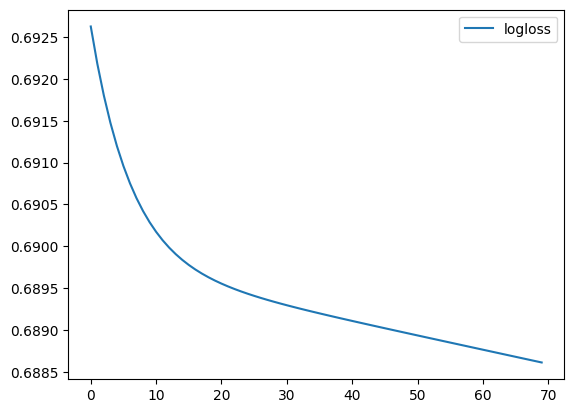

In [12]:
import matplotlib.pyplot as plt
settings_4 = ExperimentSettings(
    learning_rate = 0.01,
    number_epochs = 70,
    batch_size = 20,
    input_features = ['length'],
    optimizer = "batch",
    model_name = "logistic_regression"
)

model_4 = create_model(settings_4)
experiment_4 = train_model(
    experiment_name = "one_feature",
    model = model_4,
    dataset = irisdata,
    label_name = "Type_binary",
    settings = settings_4
    
)
experiment_4["metrics_history"][["logloss"]].plot()
plt.show()

apply the two other varients of gradient descent.

Mini-batch GD

Stochastic GD

In [ ]:
def train_model(experiment_name: str,
                model: LogisticRegressionModel,
                dataset: pd.DataFrame,
                label_name: str,
                settings: ExperimentSettings,
                verbose: bool = True):

    X = dataset[settings.input_features].values
    y = dataset[label_name].values
    n_samples = len(y)

    history = {"logloss": []}

    for epoch in range(settings.number_epochs):

        indices = np.random.permutation(n_samples)
        X = X[indices]
        y = y[indices]

        if model.optimizer == "batch":

            dw, db = model.compute_gradients(X, y)
            model.update_parameters(dw, db)

        elif model.optimizer == "mini_batch":

            for i in range(0, n_samples, model.batch_size):
                X_batch = X[i:i + model.batch_size]
                y_batch = y[i:i + model.batch_size]

                dw, db = model.compute_gradients(X_batch, y_batch)
                model.update_parameters(dw, db)

        elif model.optimizer == "stochastic":

            for i in range(n_samples):
                X_i = X[i:i+1]      
                y_i = y[i:i+1]

                dw, db = model.compute_gradients(X_i, y_i)
                model.update_parameters(dw, db)

        else:
            raise ValueError("Unsupported optimizer: choose 'batch', 'mini_batch', or 'stochastic'")

        y_pred_prob = model.predict_probability(X)
        logloss = model.logloss(y, y_pred_prob)
        history["logloss"].append(logloss)

        if verbose:
            print(f"Epoch {epoch+1:03d}/{settings.number_epochs} | "
                  f"LogLoss: {logloss:.4f} | "
                  f"Weights: {model.weights} | Bias: {model.bias:.4f}")

    return {
        "name": experiment_name,
        "settings": settings,
        "model": model,
        "metrics_history": pd.DataFrame(history)
    }


Epoch 001/70 | LogLoss: 0.6911 | Weights: [-0.01035137] | Bias: 0.0002
Epoch 002/70 | LogLoss: 0.6900 | Weights: [-0.0196186] | Bias: 0.0007
Epoch 003/70 | LogLoss: 0.6897 | Weights: [-0.02395368] | Bias: 0.0020
Epoch 004/70 | LogLoss: 0.6896 | Weights: [-0.02379616] | Bias: 0.0041
Epoch 005/70 | LogLoss: 0.6894 | Weights: [-0.02696418] | Bias: 0.0056
Epoch 006/70 | LogLoss: 0.6893 | Weights: [-0.02877995] | Bias: 0.0074
Epoch 007/70 | LogLoss: 0.6892 | Weights: [-0.03115255] | Bias: 0.0091
Epoch 008/70 | LogLoss: 0.6891 | Weights: [-0.03182918] | Bias: 0.0111
Epoch 009/70 | LogLoss: 0.6890 | Weights: [-0.03179828] | Bias: 0.0132
Epoch 010/70 | LogLoss: 0.6890 | Weights: [-0.03402434] | Bias: 0.0149
Epoch 011/70 | LogLoss: 0.6889 | Weights: [-0.03441982] | Bias: 0.0169
Epoch 012/70 | LogLoss: 0.6888 | Weights: [-0.03423584] | Bias: 0.0190
Epoch 013/70 | LogLoss: 0.6887 | Weights: [-0.03454852] | Bias: 0.0211
Epoch 014/70 | LogLoss: 0.6886 | Weights: [-0.03459864] | Bias: 0.0231
Epoch 0

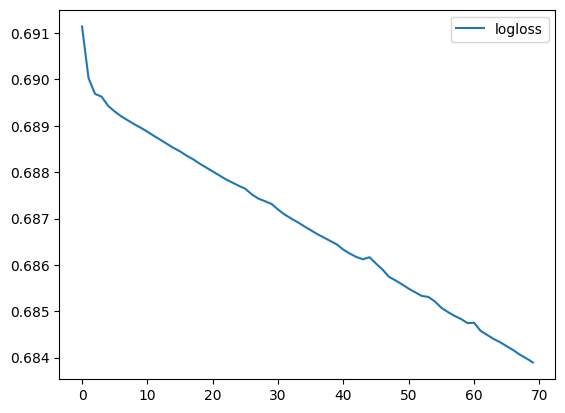

In [18]:
import matplotlib.pyplot as plt
settings_5 = ExperimentSettings(
    learning_rate = 0.01,
    number_epochs = 70,
    batch_size = 20,
    input_features = ['length'],
    optimizer = "mini_batch",
    model_name = "logistic_regression"
)

model_5 = create_model(settings_5)
experiment_5 = train_model(
    experiment_name = "one_feature",
    model = model_5,
    dataset = irisdata,
    label_name = "Type_binary",
    settings = settings_5
    
    
)
experiment_5["metrics_history"][["logloss"]].plot()
plt.show()

Epoch 001/70 | LogLoss: 0.6926 | Weights: [-0.002325] | Bias: 0.0000
Epoch 002/70 | LogLoss: 0.6922 | Weights: [-0.00447365] | Bias: 0.0000
Epoch 003/70 | LogLoss: 0.6918 | Weights: [-0.00645979] | Bias: 0.0001
Epoch 004/70 | LogLoss: 0.6915 | Weights: [-0.00829614] | Bias: 0.0002
Epoch 005/70 | LogLoss: 0.6912 | Weights: [-0.00999448] | Bias: 0.0003
Epoch 006/70 | LogLoss: 0.6910 | Weights: [-0.01156563] | Bias: 0.0004
Epoch 007/70 | LogLoss: 0.6908 | Weights: [-0.01301958] | Bias: 0.0006
Epoch 008/70 | LogLoss: 0.6906 | Weights: [-0.01436553] | Bias: 0.0008
Epoch 009/70 | LogLoss: 0.6904 | Weights: [-0.01561195] | Bias: 0.0010
Epoch 010/70 | LogLoss: 0.6903 | Weights: [-0.01676665] | Bias: 0.0012
Epoch 011/70 | LogLoss: 0.6902 | Weights: [-0.01783683] | Bias: 0.0014
Epoch 012/70 | LogLoss: 0.6901 | Weights: [-0.01882911] | Bias: 0.0016
Epoch 013/70 | LogLoss: 0.6900 | Weights: [-0.01974961] | Bias: 0.0019
Epoch 014/70 | LogLoss: 0.6899 | Weights: [-0.02060394] | Bias: 0.0022
Epoch 01

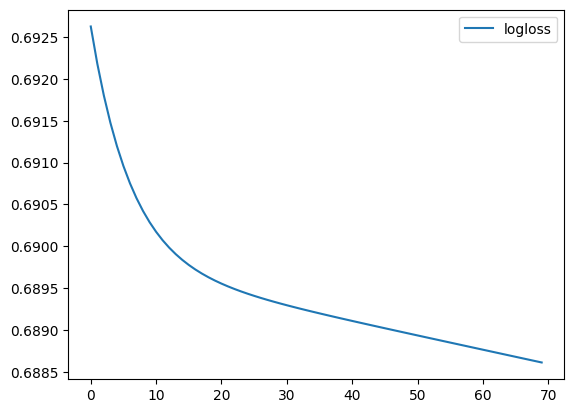

In [19]:
import matplotlib.pyplot as plt
settings_6 = ExperimentSettings(
    learning_rate = 0.01,
    number_epochs = 70,
    batch_size = 20,
    input_features = ['length'],
    optimizer = "batch",
    model_name = "logistic_regression"
)

model_6 = create_model(settings_6)
experiment_6 = train_model(
    experiment_name = "one_feature",
    model = model_6,
    dataset = irisdata,
    label_name = "Type_binary",
    settings = settings_6
    
    
)
experiment_6["metrics_history"][["logloss"]].plot()
plt.show()

Epoch 001/70 | LogLoss: 0.7007 | Weights: [-0.0925433] | Bias: 0.0252
Epoch 002/70 | LogLoss: 0.7366 | Weights: [0.06815155] | Bias: 0.0971
Epoch 003/70 | LogLoss: 0.6847 | Weights: [-0.05286403] | Bias: 0.1177
Epoch 004/70 | LogLoss: 0.6862 | Weights: [-0.08725457] | Bias: 0.1544
Epoch 005/70 | LogLoss: 0.6813 | Weights: [-0.06854528] | Bias: 0.1996
Epoch 006/70 | LogLoss: 0.7043 | Weights: [-0.15262361] | Bias: 0.2267
Epoch 007/70 | LogLoss: 0.6892 | Weights: [-0.13393215] | Bias: 0.2720
Epoch 008/70 | LogLoss: 0.6763 | Weights: [-0.0916461] | Bias: 0.3209
Epoch 009/70 | LogLoss: 0.6765 | Weights: [-0.11556308] | Bias: 0.3552
Epoch 010/70 | LogLoss: 0.6789 | Weights: [-0.13992934] | Bias: 0.3927
Epoch 011/70 | LogLoss: 0.7020 | Weights: [-0.19724775] | Bias: 0.4226
Epoch 012/70 | LogLoss: 0.6699 | Weights: [-0.11443149] | Bias: 0.4789
Epoch 013/70 | LogLoss: 0.6694 | Weights: [-0.13941158] | Bias: 0.5148
Epoch 014/70 | LogLoss: 0.6835 | Weights: [-0.19515103] | Bias: 0.5437
Epoch 015

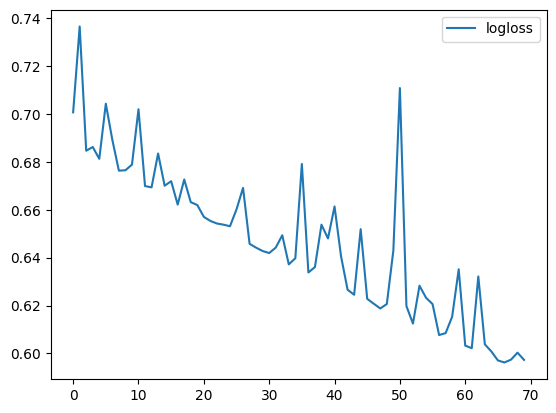

In [20]:
import matplotlib.pyplot as plt
settings_7 = ExperimentSettings(
    learning_rate = 0.01,
    number_epochs = 70,
    batch_size = 20,
    input_features = ['length'],
    optimizer = "stochastic",
    model_name = "logistic_regression"
)

model_7 = create_model(settings_7)
experiment_7 = train_model(
    experiment_name = "one_feature",
    model = model_7,
    dataset = irisdata,
    label_name = "Type_binary",
    settings = settings_7
    
    
)
experiment_7["metrics_history"][["logloss"]].plot()
plt.show()